<center><span style="font-size:35px; font-weight:bold; color:darkblue;">
    TRANSFORMER
</span></center>

## Import library

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

## Data Preparation

In [2]:
# Đọc dữ liệu từ CSV
df = pd.read_csv("data_preprocessed/data_features_m01.csv")

# Tách cột đặc trưng và nhãn
X = df.drop('label', axis=1)
y = df['label']

# Chuẩn hóa bằng StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode emotion labels as integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [3]:
# One-hot encode nhãn
num_classes = len(le.classes_)
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

# Định dạng đầu vào cho Transformer (3D: samples, sequence_length, features)
X_train_tf = tf.convert_to_tensor(X_train.reshape(X_train.shape[0], 1, X_train.shape[1]), dtype=tf.float32)
X_test_tf = tf.convert_to_tensor(X_test.reshape(X_test.shape[0], 1, X_test.shape[1]), dtype=tf.float32)


In [4]:
# Declare the path to save the best Transformer model
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_transformer_model_m01.h5")

## Build model

In [5]:
# Hàm tạo một encoder block của Transformer
def transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=256, dropout=0.1):
    # Multi-head self-attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(inputs, inputs)
    attn = layers.Dropout(dropout)(attn)
    out1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attn)  

    # Feed-forward network
    ff = layers.Dense(ff_dim, activation="relu")(out1)
    ff = layers.Dense(inputs.shape[-1])(ff)
    ff = layers.Dropout(dropout)(ff)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ff)

    return out2

# Hàm tạo mô hình Transformer đầy đủ
def build_transformer_model(input_shape, num_classes, num_blocks=3):
    inputs = Input(shape=input_shape)
    x = inputs

    for _ in range(num_blocks):  # stack nhiều encoder blocks
        x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=256, dropout=0.1)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)

# Khởi tạo và compile mô hình
model = build_transformer_model(input_shape=(1, X_train.shape[1]), num_classes=num_classes)
model.compile(
    optimizer=Adam(learning_rate=0.0005),  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 1, 40)]              0         []                            
                                                                                                  
 multi_head_attention (Mult  (None, 1, 40)                41768     ['input_1[0][0]',             
 iHeadAttention)                                                     'input_1[0][0]']             
                                                                                                  
 dropout (Dropout)           (None, 1, 40)                0         ['multi_head_attention[0][0]']
                                                                                                  
 tf.__operators__.add (TFOp  (None, 1, 40)                0         ['input_1[0][0]',         

## Train model

In [6]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

# Giảm learning rate khi val_loss không cải thiện
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

# Lưu best model ra file .h5
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

# Gộp tất cả callback
callbacks = [checkpoint, early_stop, lr_scheduler]

history = model.fit(
    X_train_tf,
    y_train_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print("Best model saved at:", BEST_MODEL_PATH)
print("File exists:", os.path.exists(BEST_MODEL_PATH))

Epoch 1/100
94/98 [===========================>..] - ETA: 0s - loss: 1.3570 - accuracy: 0.4292   
Epoch 1: val_accuracy improved from -inf to 0.55202, saving model to models\best_transformer_model_m01.h5
98/98 [==============================] - 9s 19ms/step - loss: 1.3504 - accuracy: 0.4341 - val_loss: 1.0579 - val_accuracy: 0.5520 - lr: 5.0000e-04
Epoch 2/100
 1/98 [..............................] - ETA: 0s - loss: 1.2498 - accuracy: 0.4375

D:\ANACONDA\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


96/98 [============================>.] - ETA: 0s - loss: 1.0467 - accuracy: 0.5732
Epoch 2: val_accuracy improved from 0.55202 to 0.63295, saving model to models\best_transformer_model_m01.h5
98/98 [==============================] - 1s 13ms/step - loss: 1.0451 - accuracy: 0.5746 - val_loss: 0.9026 - val_accuracy: 0.6329 - lr: 5.0000e-04
Epoch 3/100
95/98 [============================>.] - ETA: 0s - loss: 0.9088 - accuracy: 0.6355
Epoch 3: val_accuracy improved from 0.63295 to 0.69942, saving model to models\best_transformer_model_m01.h5
98/98 [==============================] - 1s 14ms/step - loss: 0.9083 - accuracy: 0.6360 - val_loss: 0.7786 - val_accuracy: 0.6994 - lr: 5.0000e-04
Epoch 4/100
92/98 [===========================>..] - ETA: 0s - loss: 0.8214 - accuracy: 0.6797
Epoch 4: val_accuracy improved from 0.69942 to 0.70520, saving model to models\best_transformer_model_m01.h5
98/98 [==============================] - 1s 14ms/step - loss: 0.8210 - accuracy: 0.6810 - val_loss: 0.7723

## Predict on test set

In [7]:
# Dự đoán
y_pred_probs = model.predict(X_test_tf)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

27/27 [==============================] - 1s 3ms/step


## Evaluation

In [8]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))



Classification Report:
              precision    recall  f1-score   support

       angry     0.9355    0.9062    0.9206       192
     disgust     0.9301    0.9010    0.9153       192
        fear     0.9206    0.9062    0.9134       192
     neutral     0.9121    0.8646    0.8877        96
         sad     0.8538    0.9427    0.8960       192

    accuracy                         0.9086       864
   macro avg     0.9104    0.9042    0.9066       864
weighted avg     0.9102    0.9086    0.9087       864



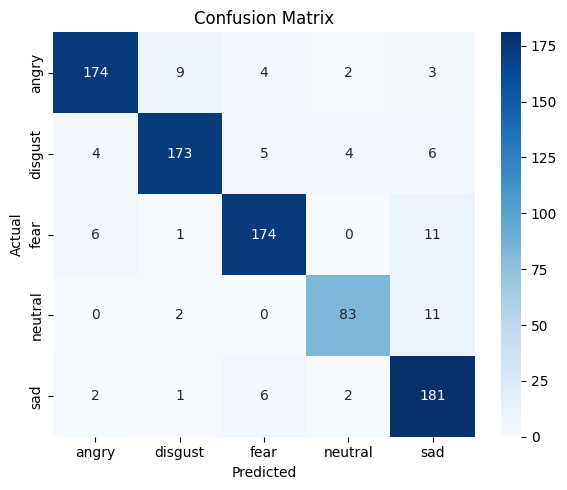

In [9]:
# Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [10]:
# Cohen’s Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")

Cohen's Kappa: 0.8842


In [11]:
# # Vẽ learning curves
# plt.figure(figsize=(12, 4))

# # Accuracy
# plt.subplot(1, 2, 1)
# plt.plot(history.history['accuracy'], label='Train')
# plt.plot(history.history['val_accuracy'], label='Validation')
# plt.title('Model Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()

# # Loss
# plt.subplot(1, 2, 2)
# plt.plot(history.history['loss'], label='Train')
# plt.plot(history.history['val_loss'], label='Validation')
# plt.title('Model Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.tight_layout()
# plt.show()


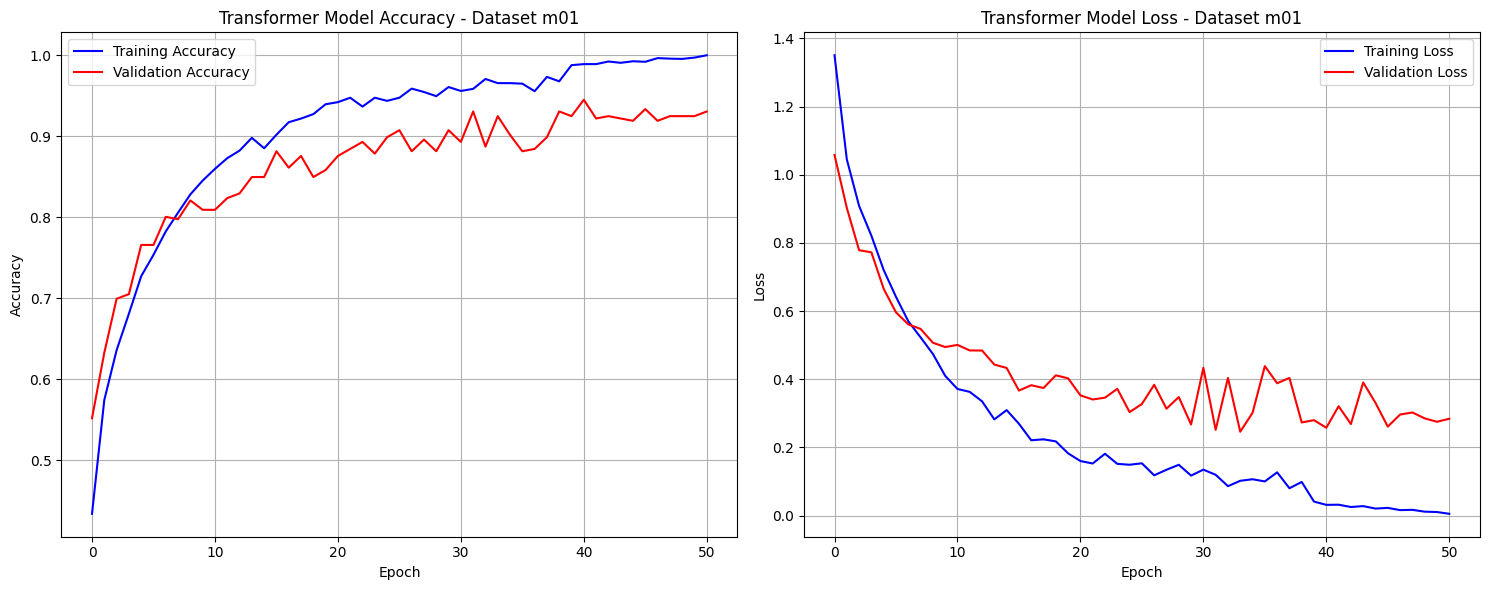

Training history plots generated!


In [12]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('Transformer Model Accuracy - Dataset m01')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('Transformer Model Loss - Dataset m01')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Training history plots generated!")